# Salary Predictions
---

The task is to create a ML model that takes a set of features (Age, Gender, Education, Job title, Years of Experience) And to predict the excpected Salary

## Importing Libraries

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler


## Data Exploration

In [ ]:
# Use pandas to read the data
df=pd.read_csv("Salary_Data[1].csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.shape

(6704, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
df.duplicated().sum()

np.int64(4912)

In [ ]:
df[df.duplicated()].sort_values(by="Age")

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
5057,21.0,Female,High School,Junior Sales Representative,0.0,25000.0
4910,21.0,Female,High School,Junior Sales Representative,0.0,25000.0
5083,21.0,Female,High School,Junior Sales Representative,0.0,25000.0
4897,21.0,Female,High School,Junior Sales Representative,0.0,25000.0
5122,21.0,Female,High School,Junior Sales Representative,0.0,25000.0
...,...,...,...,...,...,...
1277,61.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1304,62.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1305,62.0,Male,PhD,Software Engineer Manager,19.0,200000.0
1258,62.0,Male,PhD,Software Engineer Manager,19.0,200000.0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1792, 6)

In [ ]:
df.isna().sum()                          #Check null values

,0
Age,1
Gender,1
Education Level,2
Job Title,1
Years of Experience,2
Salary,4


## Visualization

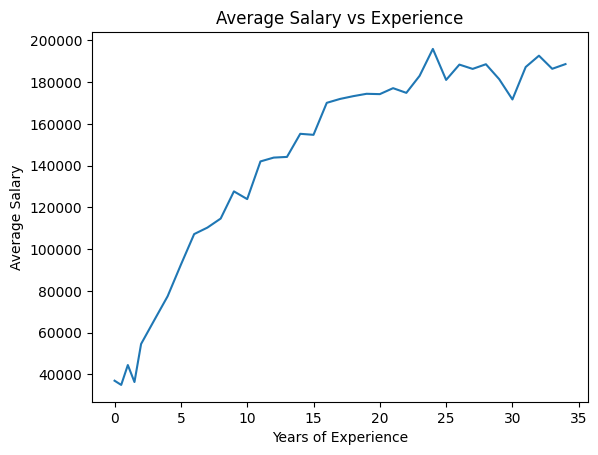

In [ ]:
avg_salary = df.groupby("Years of Experience")["Salary"].mean()

avg_salary.plot()
plt.title("Average Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary")
plt.show()

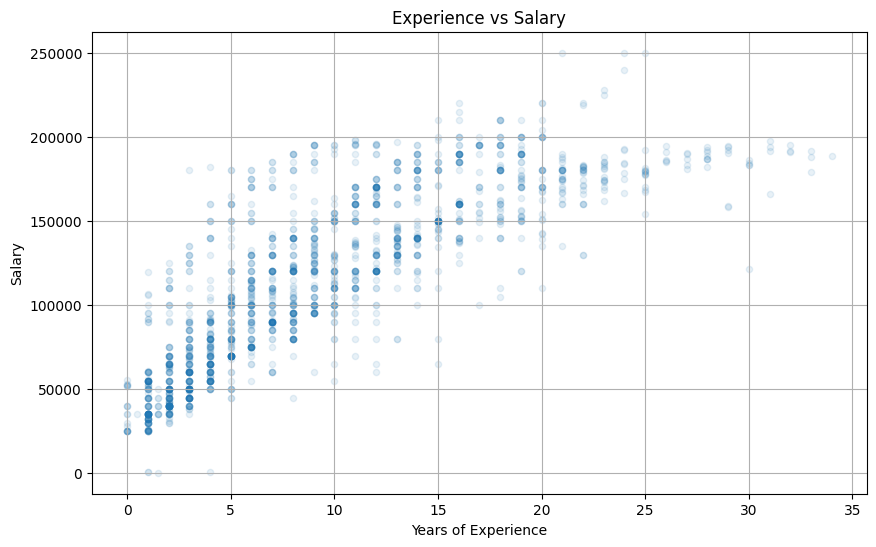

In [ ]:
df.plot(
    kind="scatter",
    x="Years of Experience",
    y="Salary",
    alpha=0.1,
    grid=True,
    figsize=(10, 6)
)

plt.title("Experience vs Salary")
plt.show()

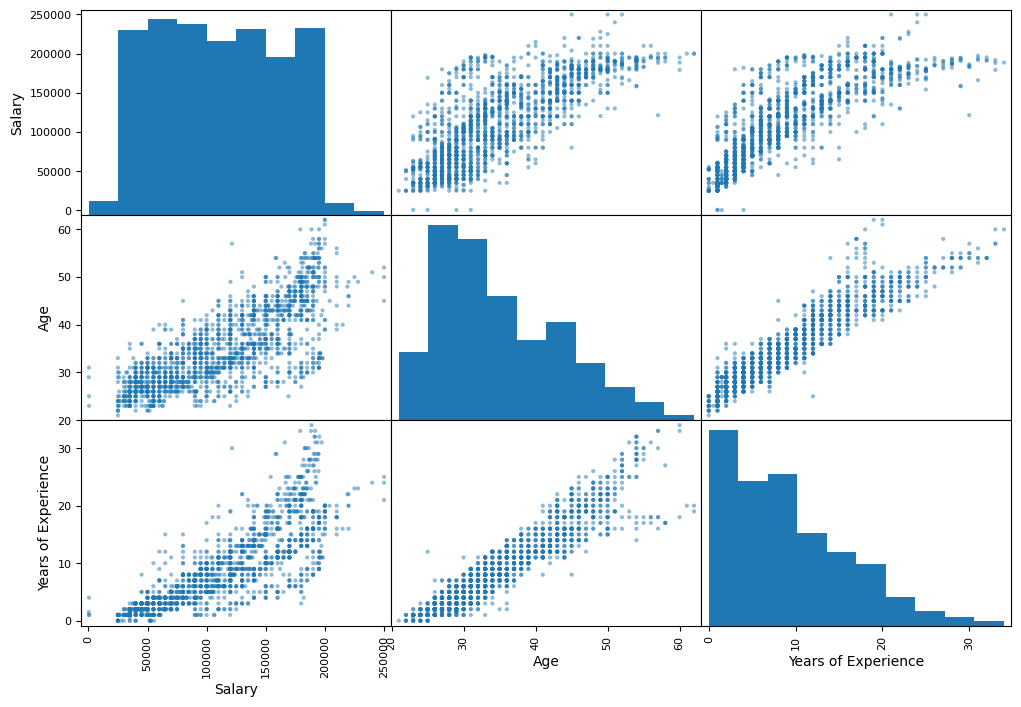

In [ ]:

attributes = [
    "Salary",
    "Age",
    "Years of Experience",
     "Education Level",
    "Gender"

]

scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

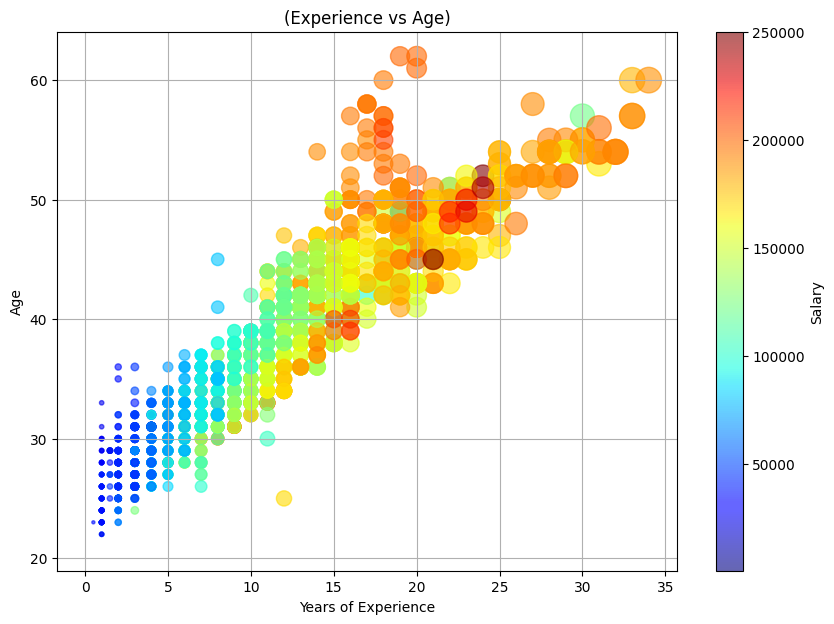

In [ ]:
df.plot(
    kind="scatter",
    x="Years of Experience",
    y="Age",
    grid=True,
    s=df["Years of Experience"] * 10,
    c="Salary",
    cmap="jet",
    colorbar=True,
    alpha=0.6,
    figsize=(10, 7)
)

plt.title("(Experience vs Age)")
plt.show()

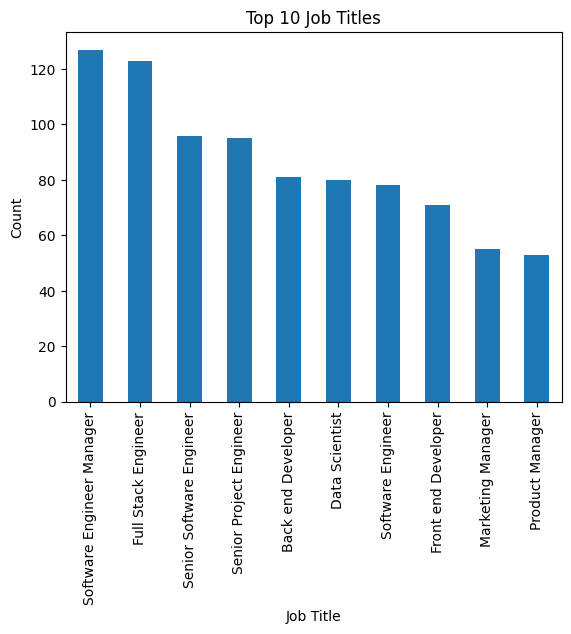

In [ ]:
top_jobs = df["Job Title"].value_counts().head(10)

top_jobs.plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.ylabel("Count")
plt.show()


## Data Cleaning

In [ ]:
# Get total number of valid Gender rows and na ones
row_numbers = df[df['Gender'].isin(['Male', 'Female'])].index
null_gender = df[df['Gender'].isna()]
print(null_gender)

     Age Gender Education Level Job Title  Years of Experience  Salary
172  NaN    NaN             NaN       NaN                  NaN     NaN


In [ ]:
# Drops NaN Gender indices
df.drop(null_gender.index,inplace=True)

In [ ]:
# df = df[df['Gender'] != 'Other']                    #drop gender type other if it's not important
# df = df.dropna(subset=['Gender'])

In [ ]:
null_yearsofexperience = df[df['Years of Experience'].isna()]

print(null_yearsofexperience)

       Age  Gender    Education Level Job Title  Years of Experience  Salary
5247  26.0  Female  Bachelor's Degree  Social M                  NaN     NaN


In [ ]:
df.drop(null_yearsofexperience.index,inplace=True,axis=0)    # dropping nan years&salary


In [ ]:
null_educationlevel = df[df['Education Level'].isna()]

print(null_educationlevel)

       Age Gender Education Level  Job Title  Years of Experience    Salary
2011  27.0   Male             NaN  Developer                  7.0  100000.0


In [ ]:
df.drop(null_educationlevel.index,inplace=True,axis=0)


In [ ]:
null_salary = df[df['Salary'].isna()]

print(null_salary)

       Age Gender    Education Level            Job Title  \
3136  31.0   Male    Master's Degree  Full Stack Engineer   
6455  36.0   Male  Bachelor's Degree       Sales Director   

      Years of Experience  Salary  
3136                  8.0     NaN  
6455                  6.0     NaN  


In [ ]:
 #  using group by to fill salary based on years of experience
dfcopy = df.copy()

null_salary = dfcopy["Salary"].isnull()

dfcopy["Salary"] = dfcopy.groupby("Years of Experience")["Salary"]\
.transform(lambda x: x.fillna(x.median()))

dfcopy.loc[null_salary]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,107895.0
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,100358.0


In [ ]:
dfcopy.isna().sum()                  # Check if dfcopy doesn't have NULL values

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1789 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1789 non-null   float64
 1   Gender               1789 non-null   object 
 2   Education Level      1789 non-null   object 
 3   Job Title            1789 non-null   object 
 4   Years of Experience  1789 non-null   float64
 5   Salary               1789 non-null   float64
dtypes: float64(3), object(3)
memory usage: 97.8+ KB


In [ ]:
dfcopy.describe()

,Age,Years of Experience,Salary
count,1789.000000,1789.000000,1789.000000
mean,35.138066,9.153717,113174.533259
std,8.209059,6.841556,51568.714475
min,21.000000,0.000000,350.000000
25%,29.000000,3.000000,70000.000000
50%,33.000000,8.000000,110000.000000
75%,41.000000,13.000000,160000.000000
max,62.000000,34.000000,250000.000000


## Outliers

In [ ]:
# Using Box Plot to split the data into quarters where IQR = Q3 - Q1
# IQR is the median of the data and any thing < lower_bound (Q1 - 1.5 IQR) or any thing > upper_bound (Q2 + 1.5 IQR)
# is considered an outlier
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
lower_bound = Q1 - 1.5 * (Q3 - Q1)
upper_bound = Q3 + 1.5 * (Q3 - Q1)
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(outliers)
outliers.shape

Number of outliers: 0
Empty DataFrame
Columns: [Age, Gender, Education Level, Job Title, Years of Experience, Salary]
Index: []


(0, 6)

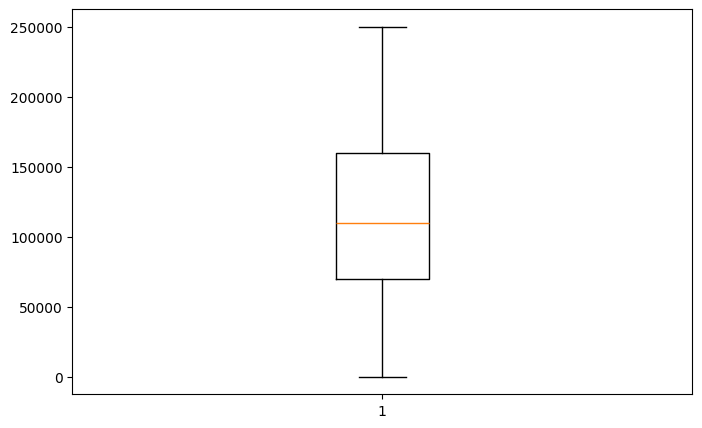

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Salary"].dropna())
plt.show()

## Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

le = LabelEncoder()

dfcopy["Gender"] = le.fit_transform(df["Gender"])
#male-->1   female-->0

In [ ]:
dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1789 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1789 non-null   float64
 1   Gender               1789 non-null   int64  
 2   Education Level      1789 non-null   object 
 3   Job Title            1789 non-null   object 
 4   Years of Experience  1789 non-null   float64
 5   Salary               1789 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 97.8+ KB


In [ ]:
dfcopy["Education Level"].value_counts()

,count
Education Level,
Bachelor's Degree,507
Master's Degree,447
PhD,340
Bachelor's,262
Master's,122
High School,110
phD,1


In [ ]:
# Map same data that has different names to a common name
dfcopy["Education Level"] = dfcopy["Education Level"].replace({
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree": "Master's",
    "phD":"PhD"
})

In [ ]:
dfcopy["Education Level"].value_counts()

,count
Education Level,
Bachelor's,769
Master's,569
PhD,341
High School,110


In [ ]:
mapping = {"High School": 0,"Bachelor's": 1,"Master's": 2,"PhD": 3}
dfcopy["Education Level"] = dfcopy["Education Level"].map(mapping)

In [ ]:
dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1789 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1789 non-null   float64
 1   Gender               1789 non-null   int64  
 2   Education Level      1789 non-null   int64  
 3   Job Title            1789 non-null   object 
 4   Years of Experience  1789 non-null   float64
 5   Salary               1789 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 97.8+ KB


In [ ]:
dfcopy["Job Title"].value_counts()

,count
Job Title,
Software Engineer Manager,127
Full Stack Engineer,123
Senior Software Engineer,96
Senior Project Engineer,95
Back end Developer,81
...,...
Junior Research Scientist,1
Senior Product Development Manager,1
Junior Social Media Specialist,1


<Axes: >

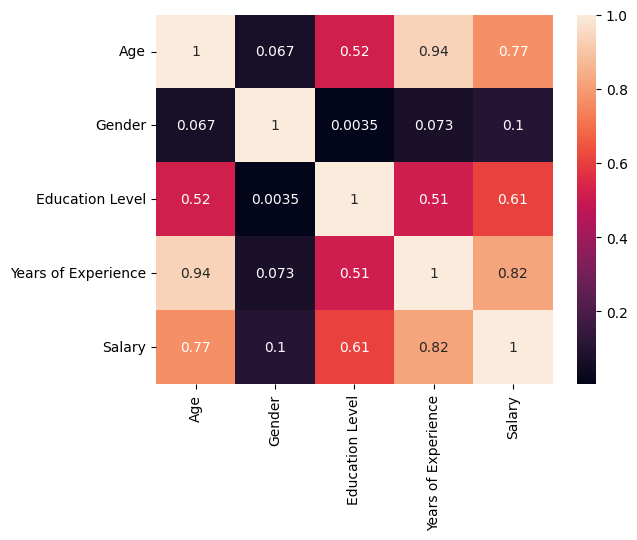

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(dfcopy.corr(numeric_only=True),annot=True)
# Its clear that Salary is correlated with Years of Experience and Age

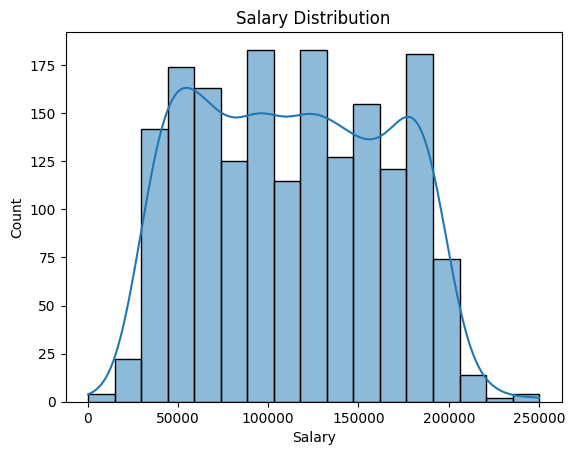

In [ ]:
sns.histplot(dfcopy["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()
# Multimodal distribution

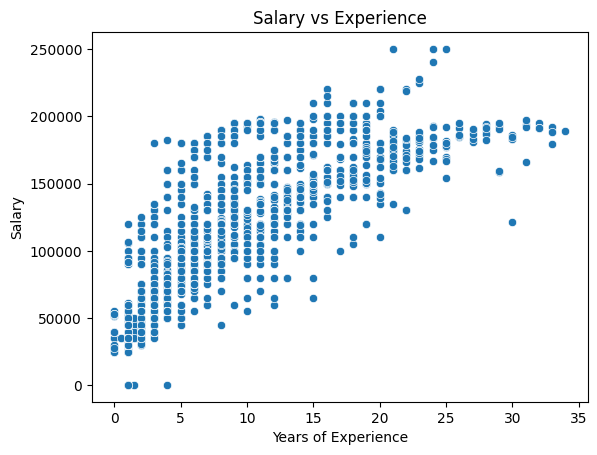

In [ ]:
sns.scatterplot(x="Years of Experience", y="Salary", data=df)
plt.title("Salary vs Experience")
plt.show()
# Show the reloation of YOE with Salary

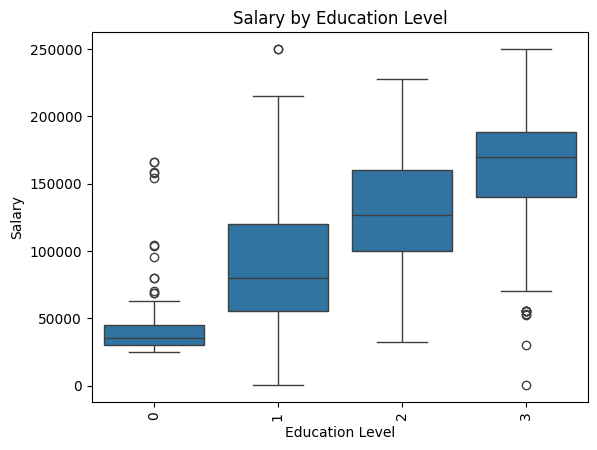

In [ ]:
sns.boxplot(x="Education Level", y="Salary", data=dfcopy)
plt.title("Salary by Education Level")
plt.xticks(rotation=90)
plt.show()
#"High School": 0,"Bachelor's": 1,"Master's": 2,"PhD": 3
# There is alot of outliers at PhD and High School Level

## Training the Model

In [ ]:
from sklearn.model_selection import train_test_split
Y=dfcopy["Salary"]
X=dfcopy.drop("Salary",axis=1)
# Y is the output the model is trying to guess
# X is the Features

In [ ]:
X

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,1,Software Engineer,5.0
1,28.0,0,2,Data Analyst,3.0
2,45.0,1,3,Senior Manager,15.0
3,36.0,0,1,Sales Associate,7.0
4,52.0,1,2,Director,20.0
...,...,...,...,...,...
6623,43.0,0,2,Digital Marketing Manager,15.0
6624,27.0,1,0,Sales Manager,2.0
6625,33.0,0,1,Director of Marketing,8.0
6628,37.0,1,1,Sales Director,7.0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=.8,random_state=42,shuffle=True)
#

In [ ]:
# Temp variable to calculate job_mean
train_data = x_train.copy()
train_data["Salary"] = y_train

job_mean = train_data.groupby("Job Title")["Salary"].mean()

# Encode the job title with the salary mean
# Since we don't care about Job Title but rather
# Its median and Years of Experience, Its ok

x_train["Job Title"] = x_train["Job Title"].map(job_mean)
x_test["Job Title"] = x_test["Job Title"].map(job_mean)
x_test = x_test.fillna(y_train.mean())


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
import numpy as np

print(np.mean(x_train_scaled, axis=0))
print(np.std(x_train_scaled, axis=0))

[ 0.17767296 -0.45283019 -0.37037037 -0.08224295  0.12559205]
[0.68050666 0.50612326 0.85483935 0.65821798 0.75099439]


## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error


In [ ]:
reg=LinearRegression()

In [ ]:
reg.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
reg.intercept_

np.float64(113107.43580681246)

In [ ]:
reg.coef_

array([ 7184.20394107,  2944.15710259,  2469.85054557, 36049.67378507,
       28006.24602603])

In [ ]:
y_predict=reg.predict(x_test_scaled)

In [ ]:
r2_score(y_true=y_test,y_pred=y_predict)

0.7775520630724191

In [ ]:
mean_squared_error(y_true=y_test,y_pred=y_predict)

622012273.3775331

In [ ]:
root_mean_squared_error(y_true=y_test,y_pred=y_predict)

24940.17388426819

## Trying Different Models

In [ ]:
LinearRegressionModel = LinearRegression(fit_intercept=True,n_jobs=-1)
SGDRegressionModel = SGDRegressor(alpha=0.1,random_state=33,penalty='l2',loss = 'huber')
LassoRegressionModel = Lasso(alpha=1.0,random_state=33)
RidgeRegressionModel = Ridge(alpha=1.0,random_state=33)
RandomForestRegressorModel = RandomForestRegressor(n_estimators=1000,max_depth=8, random_state=33)
GBRModel = GradientBoostingRegressor(n_estimators=500,max_depth=7,learning_rate = 0.2 ,random_state=33)
SVRModel = SVR(C = 1.0 ,epsilon=0.1,kernel = 'rbf')
DecisionTreeRegressorModel = DecisionTreeRegressor( max_depth=3,random_state=33)
KNeighborsRegressorModel = KNeighborsRegressor(n_neighbors = 5, weights='uniform',algorithm = 'auto')


Models = [LinearRegressionModel,SGDRegressionModel,LassoRegressionModel,RidgeRegressionModel,RandomForestRegressorModel,
          GBRModel,SVRModel,DecisionTreeRegressorModel,KNeighborsRegressorModel]





for Model in Models :
    print(f'for Model {str(Model).split("(")[0]}')
    Model.fit(x_train_scaled, y_train)
    y_pred = Model.predict(x_test_scaled)
    print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
    print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
    print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
    print('=================================================')

for Model LinearRegression
MAE value is  : 18423.088190159957
MSE value is  : 622012273.3775331
MdSE value is  : 12836.10700246055
for Model SGDRegressor
MAE value is  : 115061.99517673466
MSE value is  : 16035488418.41509
MdSE value is  : 118814.96694839405
for Model Lasso
MAE value is  : 18423.052018357932
MSE value is  : 622033461.7709696
MdSE value is  : 12840.879747276296
for Model Ridge
MAE value is  : 18424.35810763686
MSE value is  : 622056445.874809
MdSE value is  : 12881.739821165414
for Model RandomForestRegressor


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


MAE value is  : 12589.676732698203
MSE value is  : 343046605.73317367
MdSE value is  : 7155.355423775749
for Model GradientBoostingRegressor
MAE value is  : 10895.116871422908
MSE value is  : 342201984.0121731
MdSE value is  : 5604.628436726602
for Model SVR
MAE value is  : 45808.58177017007
MSE value is  : 2805746563.095134
MdSE value is  : 45012.95947270012
for Model DecisionTreeRegressor
MAE value is  : 19025.087058956895
MSE value is  : 680990876.4888465
MdSE value is  : 13856.674999999988
for Model KNeighborsRegressor
MAE value is  : 14870.118435754192
MSE value is  : 452461786.3418994
MdSE value is  : 9104.799999999988


## Parameters Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define the Parameter Grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search_gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=33),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_gbr.fit(x_train_scaled, y_train)

GBRModel = grid_search_gbr.best_estimator_
print("Best Parameters found:", grid_search_gbr.best_params_)

y_predict_gbr = GBRModel.predict(x_test_scaled)

Best Parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


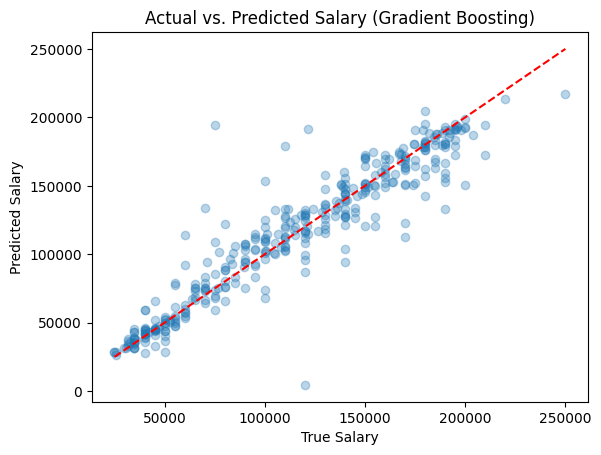

In [ ]:
GBRModel = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=33
)

GBRModel.fit(x_train_scaled, y_train)

y_pred = GBRModel.predict(x_test_scaled)

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs. Predicted Salary (Gradient Boosting)")
plt.show()